# 1. Imports and Setup

In [28]:
import itertools
from collections import deque
from fractions import Fraction as Fr
from IPython.display import display

import numpy as np
from sympy import (symbols, factor, factor_list, degree,
                   Matrix, Rational, Poly, eye, prod as sym_prod)

x_sym = symbols('x') # Define x_sym globally for convenience

# 2. Graph Construction: Klein Graph (PSL(2,7))

In [29]:
def _build_PSL27():
    F = 7
    def mm(A, B):
        return tuple(tuple(sum(A[i][k]*B[k][j] for k in range(2)) % F
                           for j in range(2)) for i in range(2))
    def det(A): return (A[0][0]*A[1][1] - A[0][1]*A[1][0]) % F
    def neg(A): return tuple(tuple((-x) % F for x in r) for r in A)
    def canon(A): return min(A, neg(A))
    SL = [((a,b),(c,d)) for a,b,c,d in itertools.product(range(F), repeat=4)
          if det(((a,b),(c,d))) == 1]
    PSL = sorted(set(canon(A) for A in SL))
    assert len(PSL) == 168
    def mul(A, B): return canon(mm(A, B))
    return PSL, mul

def build_klein_graph():
    PSL, mul = _build_PSL27()
    F = 7
    def neg(A): return tuple(tuple((-x)%F for x in r) for r in A)
    def canon(A): return min(A, neg(A))
    e = canon(((1,0),(0,1)))
    g = canon(((1,1),(0,1)))
    H = set(); cur = e
    for _ in range(7): H.add(cur); cur = mul(cur, g)
    assert len(H) == 7
    def coset(ge): return frozenset(mul(ge, h) for h in H)
    cosets, idx = [], {}
    for ge in PSL:
        c = coset(ge)
        if c not in idx: idx[c] = len(cosets); cosets.append(c)
    assert len(cosets) == 24
    def act(x, cs): return coset(mul(x, next(iter(cs))))
    perms = {x: tuple(idx[act(x,c)] for c in cosets) for x in PSL}
    base  = idx[coset(e)]
    edges = set()
    for p in perms.values(): edges.add((p[base], p[0]))
    A = np.zeros((24, 24), dtype=np.int64)
    for i, j in edges: A[i, j] = 1
    return A

A = build_klein_graph()
print(f"|V| = {A.shape[0]}   |E| = {A.sum()//2}   valency = {A[0].sum()}")

|V| = 24   |E| = 84   valency = 7


# 3. Intersection Numbers and Graph Verification

In [70]:
def bfs_distances(A, src, n=24):
    d = [-1]*n; d[src] = 0; q = deque([src])
    while q:
        u = q.popleft()
        for v in range(n):
            if A[u,v] and d[v] == -1: d[v] = d[u]+1; q.append(v)
    return d

def intersection_numbers(A, base, n=24):
    dist = bfs_distances(A, base, n); D = max(dist)
    subc = {i: [v for v in range(n) if dist[v]==i] for i in range(D+1)}
    b, c, a = [None]*D, [None]*(D+1), [None]*(D+1)
    for i in range(D+1):
        bv, cv, av = set(), set(), set()
        for y in subc[i]:
            nb = [v for v in range(n) if A[y,v]]
            bv.add(sum(1 for v in nb if dist[v]==i+1) if i<D else 0)
            cv.add(sum(1 for v in nb if dist[v]==i-1) if i>0 else 0)
            av.add(sum(1 for v in nb if dist[v]==i))
        assert len(bv)==len(cv)==len(av)==1
        if i<D: b[i] = bv.pop()
        c[i] = cv.pop(); a[i] = av.pop()
    return b, c, a, D, subc

n = 24; base = 3 # Hardcoded base vertex for initial analysis
b, c, a_arr, D, subc = intersection_numbers(A, base)

# Calculate and format the spectrum
eigs_raw = np.linalg.eigvalsh(A.astype(float))
eigs_rounded = np.round(eigs_raw, 4)

# Count multiplicities
from collections import Counter
eig_counts = Counter(eigs_rounded)
eigs_formatted = []
for eig_val in sorted(eig_counts.keys()):
    eigs_formatted.append(f"{eig_val}^{eig_counts[eig_val]}")

print("Spectrum (rounded):", ", ".join(eigs_formatted))
print(f"Intersection array:  b={b},  c={c[1:]}")
print(f"Subconstituent sizes: {[len(subc[i]) for i in range(D+1)]}")

Spectrum (rounded): -2.6458^8, -1.0^7, 2.6458^8, 7.0^1
Intersection array:  b=[7, 4, 1],  c=[1, 2, 7]
Subconstituent sizes: [1, 7, 14, 2]


# 4. Linear Algebra Helpers

In [32]:
def rref_add(row, br, pc):
    row = row[:]
    for b2, p in zip(br, pc):
        if row[p]:
            f = row[p]; row = [r - f*b for r,b in zip(row, b2)]
    for idx, val in enumerate(row):
        if val:
            inv = Fr(1,1)/val; row = [r*inv for r in row]
            new = []
            for b2, p in zip(br, pc):
                if b2[idx]:
                    f = b2[idx]; b2 = [b - f*r for b,r in zip(b2, row)]
                new.append(b2)
            new.append(row)
            return True, new, pc + [idx]
    return False, br, pc

def span_basis(vecs):
    br, pc = [], []
    for v in vecs: added, br, pc = rref_add(v, br, pc)
    return br

def exact_rank(vecs):
    br, pc = [], []
    for v in vecs: added, br, pc = rref_add(v, br, pc)
    return len(br)

def exact_matmul(M1, M2):
    k = len(M1)
    R = [[Fr(0)]*k for _ in range(k)]
    for i in range(k):
        for j in range(k):
            if M1[i][j]:
                for l in range(k): R[i][l] += M1[i][j]*M2[j][l]
    return R

# 5. Module Operations Helpers

In [33]:
def orbit_basis(seed, T_basis, n=24):
    vecs = []
    for M in T_basis:
        res = [Fr(0)]*n
        for i in range(n):
            s = Fr(0)
            for j in range(n): s += M[i][j]*seed[j]
            res[i] = s
        vecs.append(res)
    return span_basis(vecs)

def orbit_basis_multi(seeds, T_basis, n=24):
    all_vecs = []
    for seed in seeds:
        for M in T_basis:
            res = [Fr(0)]*n
            for i in range(n):
                s = Fr(0)
                for j in range(n): s += M[i][j]*seed[j]
                res[i] = s
            all_vecs.append(res)
    return span_basis(all_vecs)

def module_shape(orb, subc, D):
    shape = []
    for i in range(D+1):
        cols = [[orb[j][v] for j in range(len(orb))] for v in subc[i]]
        shape.append(exact_rank(cols))
    return shape

def eval_poly_on_matrix(poly_expr, M_sym, var):

    coeffs = Poly(poly_expr, var).all_coeffs()  # highest degree first
    d = M_sym.shape[0]
    result = eye(d) * Rational(0)
    for coeff in coeffs:
        result = result * M_sym + eye(d) * coeff
    return result

# 6. `A_restricted` Function

In [34]:
A_frac = [[Fr(int(A[i][j])) for j in range(24)] for i in range(24)]

def A_restricted(orb, n=24):

    d = len(orb)
    mat = [[Fr(0)]*d for _ in range(d)]
    for j, v in enumerate(orb):
        Av = [Fr(0)]*n
        for i in range(n):
            for k in range(n): Av[i] += A_frac[i][k]*v[k]
        # Solve: [w_0 | ... | w_{d-1}] * col = Av
        W = Matrix([[Rational(orb[idx][vec_idx].numerator, orb[idx][vec_idx].denominator)
                     for idx in range(d)] for vec_idx in range(n)])
        b_vec = Matrix([Rational(x.numerator, x.denominator) for x in Av])
        aug = W.row_join(b_vec)
        rref, pivots = aug.rref()
        sol = []
        for i in range(d):
            if i in list(pivots):
                ri = list(pivots).index(i)
                sol.append(rref[ri, -1])
            else:
                sol.append(Rational(0))
        for i in range(d):
            mat[i][j] = Fr(int(sol[i].p), int(sol[i].q))
    return Matrix([[Rational(mat[i][j].numerator, mat[i][j].denominator)
                   for j in range(d)] for i in range(d)])

# 7. Method 1: Terwilliger Algebra Dimension via Closure

In [35]:
def dim_terwilliger_exact(A, base, n=24):
    b, c, a, D, subc = intersection_numbers(A, base, n)
    Estar = []
    for i in range(D+1):
        M = np.zeros((n,n), dtype=np.int64)
        for x in subc[i]: M[x,x] = 1
        Estar.append(M)
    def to_fr(M): return [[Fr(int(M[i][j])) for j in range(n)] for i in range(n)]
    basis_mats = [to_fr(g) for g in [A.astype(np.int64)] + Estar]
    br, pc = [], []
    for mat in basis_mats:
        row = [x for r in mat for x in r]
        added, br, pc = rref_add(row, br, pc)
    for rnd in range(30):
        new_mats = [exact_matmul(basis_mats[i], basis_mats[j])
                    for i in range(len(basis_mats))
                    for j in range(len(basis_mats))]
        added_count = 0
        for M in new_mats:
            row = [x for r in M for x in r]
            added, br, pc = rref_add(row, br, pc)
            if added: basis_mats.append(M); added_count += 1
        print(f"  round {rnd}: dim={len(br)} (+{added_count})")
        if added_count == 0: break
    return len(br), basis_mats

dim_T1, T_basis = dim_terwilliger_exact(A, base)
print(f"\ndim T(x) = {dim_T1}")

  round 0: dim=12 (+7)
  round 1: dim=34 (+22)
  round 2: dim=47 (+13)
  round 3: dim=47 (+0)

dim T(x) = 47


# 8. Module $W_0$ Analysis (Endpoint 0)

In [36]:
e_star = []
for i in range(D+1):
    v = [Fr(0)]*n
    for x in subc[i]: v[x] = Fr(1)
    e_star.append(v)

dim_W0   = D + 1
shape_W0 = module_shape(e_star, subc, D)

M_W0  = A_restricted(e_star, n=n)
cp_W0 = factor(M_W0.charpoly(x_sym).as_expr())

print(f"W_0:  dim = {dim_W0},  shape = {shape_W0}")
print(f"      char poly = {cp_W0}")
print()
print("Matrix of A on W_0:")
print(M_W0)

W_0:  dim = 4,  shape = [1, 1, 1, 1]
      char poly = (x - 7)*(x + 1)*(x**2 - 7)

Matrix of A on W_0:
Matrix([[0, 7, 0, 0], [1, 2, 4, 0], [0, 2, 4, 1], [0, 0, 7, 0]])


# 9. Module Endpoint-1 Analysis

In [37]:
G1 = subc[1]
comp1 = []
for j in range(1, len(G1)):
    v = [Fr(0)]*n
    v[G1[0]] = Fr(1); v[G1[j]] = Fr(-1)
    comp1.append(v)

# One 9-dim sub-orbit and the full 18-dim endpoint-1 span
orb_a   = orbit_basis(comp1[0], T_basis, n=n)
orb_ep1 = orbit_basis_multi(comp1, T_basis, n=n)

dim_a   = len(orb_a)
dim_ep1 = len(orb_ep1)

shape_a   = module_shape(orb_a,   subc, D)
shape_ep1 = module_shape(orb_ep1, subc, D)

M_a   = A_restricted(orb_a, n=n)
cp_a  = factor(M_a.charpoly(x_sym).as_expr())
fl_a  = factor_list(cp_a)

print(f"T*(one seed):  dim = {dim_a},  shape = {shape_a}")
print(f"char poly (factored) = {cp_a}")
print()
print(f"Full endpoint-1 module:  dim = {dim_ep1},  shape = {shape_ep1}")
print()

# Semisimplicity check
irred_factors = fl_a[1]
min_poly_expr = sym_prod([f for f, _ in irred_factors])
print(f"Distinct irreducible factors: {[str(f) for f,_ in irred_factors]}")
print(f"Minimal polynomial (product of distinct factors): {min_poly_expr}")

min_poly_matrix = eval_poly_on_matrix(min_poly_expr, M_a, x_sym)
is_semisimple = (min_poly_matrix == eye(dim_a) * Rational(0))
print(f"\nSemisimplicity check  min_poly(A|_W) = 0: {is_semisimple}")

T*(one seed):  dim = 9,  shape = [0, 3, 6, 0]
char poly (factored) = (x + 1)**3*(x**2 - 7)**3

Full endpoint-1 module:  dim = 18,  shape = [0, 6, 12, 0]

Distinct irreducible factors: ['x + 1', 'x**2 - 7']
Minimal polynomial (product of distinct factors): (x + 1)*(x**2 - 7)

Semisimplicity check  min_poly(A|_W) = 0: True


# 10. Eigenvalue Multiplicities and Counting Classes (Partial)

In [38]:
M_ep1 = A_restricted(orb_ep1, n=n)

type_info = []
for f_expr, _ in irred_factors:
    f_on_M = eval_poly_on_matrix(f_expr, M_ep1, x_sym)
    nullity = dim_ep1 - f_on_M.rank()
    deg = degree(f_expr, x_sym)
    num_copies = nullity // deg
    type_info.append((f_expr, deg, nullity, num_copies))
    print(f"Factor {f_expr}:  deg={deg},  "
          f"nullity in {dim_ep1}-dim module={nullity},  copies={num_copies}")

Factor x + 1:  deg=1,  nullity in 18-dim module=6,  copies=6
Factor x**2 - 7:  deg=2,  nullity in 18-dim module=12,  copies=6


# 11. Module $W_c$ Analysis (Last Endpoint $D$)

In [71]:
G3     = subc[D]
nu_c   = [Fr(0)]*n
if len(G3) > 1:
    nu_c[G3[0]] = Fr(1); nu_c[G3[1]] = Fr(-1)
elif len(G3) == 1:
    nu_c[G3[0]] = Fr(1)

# Handle cases where G3 might be empty, though unlikely for DRG

orb_c  = orbit_basis(nu_c, T_basis, n=n)
dim_c  = len(orb_c)
shape_c = module_shape(orb_c, subc, D)
M_c    = A_restricted(orb_c, n=n)
cp_c   = factor(M_c.charpoly(x_sym).as_expr())
fl_c   = factor_list(cp_c)

# Semisimplicity of W_c
irred_c   = fl_c[1]
minp_c    = sym_prod([f for f, _ in irred_c])
minp_c_M  = eval_poly_on_matrix(minp_c, M_c, x_sym)
semi_c    = (minp_c_M == eye(dim_c)*Rational(0))

print(f"W_c:  dim = {dim_c},  shape = {shape_c}")
print(f"      char poly = {cp_c}")
print(f"      semisimple: {semi_c}")
print()
print("Matrix of A on W_c:")
print(M_c)
print()

# Check: W_c vs V2
v2_shape = shape_a
print(f"W_c shape {shape_c} vs endpoint-1 shape {shape_a}")
if shape_c == shape_a:
    print("W_c has the same shape as an endpoint-1 module; further analysis needed for isomorphism.")
else:
    print("Different shapes -> W_c is a distinct isomorphism class.")

W_c:  dim = 2,  shape = [0, 0, 1, 1]
      char poly = x**2 - 7
      semisimple: True

Matrix of A on W_c:
Matrix([[0, 1], [7, 0]])

W_c shape [0, 0, 1, 1] vs endpoint-1 shape [0, 3, 6, 0]
Different shapes -> W_c is a distinct isomorphism class.


# 12. Summary: Wedderburn Equation and Module Table

In [40]:
wedderburn_target = dim_T1 - dim_W0**2 - dim_c**2
print(f"Wedderburn target for endpoint-1 contribution:")
print(f"  {dim_T1} - {dim_W0}^2 - {dim_c}^2 = {wedderburn_target}")
print()

def divisors(k):
    return [d for d in range(1, k + 1) if k % d == 0]

type_candidates = []
for f_expr, deg, nullity, num_copies in type_info:
    divs = divisors(num_copies)
    type_candidates.append((f_expr, deg, num_copies, divs))

from itertools import product as iproduct
best = None
for combo in iproduct(*[tc[3] for tc in type_candidates]):
    if sum(c * type_candidates[i][1]**2
           for i, c in enumerate(combo)) == wedderburn_target:
        best = combo
        break

assert best is not None, "No valid Wedderburn factorisation found -- check computation"

print("Unique solution:")
rows = []
for i, c_i in enumerate(best):
    f_expr, deg, num_copies, _ = type_candidates[i]
    mult_i = num_copies // c_i
    print(f"  Factor {f_expr}: {c_i} isomorphism class(es), "
          f"each dim {deg}, multiplicity {mult_i}")
    rows.append((f_expr, deg, c_i, mult_i))

# Print table
print()
print("Irreducible T-modules")
print("-" * 62)
header = f"{'Module':<14}{'Endpt':>5}{'Mult':>5}{'Dim':>4}  Shape"
print(header)
print("-" * 62)

def shape_str(sh):
    return "(" + ",".join(str(x) for x in sh) + ")"

print(f"{'W_0':<14}{'0':>5}{'1':>5}{'4':>4}  {shape_str(shape_W0)}")

for idx_r, (f_expr, deg, c_i, mult_i) in enumerate(rows):
    for k in range(1, c_i+1):
        label = f"Type {chr(65+idx_r)}, cls {k}"
        print(f"""{label:<14}{'1':>5}{str(mult_i):>5}{str(deg):>4}  (from endpoint-1 module)""")

print(f"{'W_c':<14}{'2':>5}{'1':>5}{str(dim_c):>4}  {shape_str(shape_c)}")
print("-" * 62)

# Compute dim T
dim_T2 = dim_W0**2 + sum(c_i * deg**2 for _, deg, c_i, _ in rows) + dim_c**2

print()
terms = " + ".join(f"{c_i}·{deg}²" for _, deg, c_i, _ in rows)
print(f"dim T = {dim_W0}² + {terms} + {dim_c}²")
print(f"      = {dim_W0**2} + "
      + " + ".join(str(c_i*deg**2) for _, deg, c_i, _ in rows)
      + f" + {dim_c**2}")
print(f"      = {dim_T2}")

Wedderburn target for endpoint-1 contribution:
  47 - 4^2 - 2^2 = 27

Unique solution:
  Factor x + 1: 3 isomorphism class(es), each dim 1, multiplicity 2
  Factor x**2 - 7: 6 isomorphism class(es), each dim 2, multiplicity 1

Irreducible T-modules
--------------------------------------------------------------
Module        Endpt Mult Dim  Shape
--------------------------------------------------------------
W_0               0    1   4  (1,1,1,1)
Type A, cls 1     1    2   1  (from endpoint-1 module)
Type A, cls 2     1    2   1  (from endpoint-1 module)
Type A, cls 3     1    2   1  (from endpoint-1 module)
Type B, cls 1     1    1   2  (from endpoint-1 module)
Type B, cls 2     1    1   2  (from endpoint-1 module)
Type B, cls 3     1    1   2  (from endpoint-1 module)
Type B, cls 4     1    1   2  (from endpoint-1 module)
Type B, cls 5     1    1   2  (from endpoint-1 module)
Type B, cls 6     1    1   2  (from endpoint-1 module)
W_c               2    1   2  (0,0,1,1)
--------------

# 13. Final Comparison

In [41]:
dim_vertices = dim_W0 + dim_ep1 + dim_c
print(f"Dimension check:  {dim_W0} + {dim_ep1} + {dim_c} = {dim_vertices}  (|X| = {n})")
print()
print(f"Method 1  (algebra closure):      dim T = {dim_T1}")
print(f"Method 2  (module decomposition): dim T = {dim_T2}")


Dimension check:  4 + 18 + 2 = 24  (|X| = 24)

Method 1  (algebra closure):      dim T = 47
Method 2  (module decomposition): dim T = 47


# 14. Base-Vertex Independence Check

In [42]:
base2 = 0
dim_T1_v2, _ = dim_terwilliger_exact(A, base2)
print(f"dim T(x = {base})  = {dim_T1}")
print(f"dim T(x = {base2}) = {dim_T1_v2}")

  round 0: dim=12 (+7)
  round 1: dim=34 (+22)
  round 2: dim=47 (+13)
  round 3: dim=47 (+0)
dim T(x = 3)  = 47
dim T(x = 0) = 47


## 15. Generalized Base-Vertex Independence Check

To further confirm that the dimension of the Terwilliger algebra is independent of the choice of base vertex, we can systematically compute it for all possible base vertices and verify that the results are consistent.

In [63]:
all_dims = []
# Iterate through all possible vertices as base vertices
for current_base in range(n):
    print(f"Computing for base vertex: {current_base}")
    dim_T_current, _ = dim_terwilliger_exact(A, current_base, n=n)
    all_dims.append(dim_T_current)

if all(d == all_dims[0] for d in all_dims):
    print(f"\nAll computed Terwilliger algebra dimensions are consistent: {all_dims[0]}")
    print("This implies the dimension is independent of the base vertex.")
else:
    print(f"\nInconsistent Terwilliger algebra dimensions found: {all_dims}")
    print("Further investigation may be needed.")

Computing for base vertex: 0
  round 0: dim=12 (+7)
  round 1: dim=34 (+22)
  round 2: dim=47 (+13)
  round 3: dim=47 (+0)
Computing for base vertex: 1
  round 0: dim=12 (+7)
  round 1: dim=34 (+22)
  round 2: dim=47 (+13)
  round 3: dim=47 (+0)
Computing for base vertex: 2
  round 0: dim=12 (+7)
  round 1: dim=34 (+22)
  round 2: dim=47 (+13)
  round 3: dim=47 (+0)
Computing for base vertex: 3
  round 0: dim=12 (+7)
  round 1: dim=34 (+22)
  round 2: dim=47 (+13)
  round 3: dim=47 (+0)
Computing for base vertex: 4
  round 0: dim=12 (+7)
  round 1: dim=34 (+22)
  round 2: dim=47 (+13)
  round 3: dim=47 (+0)
Computing for base vertex: 5
  round 0: dim=12 (+7)
  round 1: dim=34 (+22)
  round 2: dim=47 (+13)
  round 3: dim=47 (+0)
Computing for base vertex: 6
  round 0: dim=12 (+7)
  round 1: dim=34 (+22)
  round 2: dim=47 (+13)
  round 3: dim=47 (+0)
Computing for base vertex: 7
  round 0: dim=12 (+7)
  round 1: dim=34 (+22)
  round 2: dim=47 (+13)
  round 3: dim=47 (+0)
Computing for ba

# 16. Adjacency Matrix and Dual Idempotents

In [65]:
_, _, _, D_val, subc_val = intersection_numbers(A, base, n)

Estar = []
for i in range(D_val + 1):
    M = np.zeros((n,n), dtype=np.int64)
    for x in subc_val[i]: M[x,x] = 1
    Estar.append(M)

print("Adjacency Matrix A:")
display(Matrix(A))

print("\nDual Idempotents Estar (E_i where i is the distance from the base vertex):")
for i, E in enumerate(Estar):
    print(f"E_{i}:")
    display(Matrix(E))

Adjacency Matrix A:


Matrix([
[0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
[1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1],
[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
[1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0],
[1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
[1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0],
[1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0],
[0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0],
[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1],
[0, 1, 0, 0, 1, 1, 0, 0, 0, 0


Dual Idempotents Estar (E_i where i is the distance from the base vertex):
E_0:


Matrix([
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0

E_1:


Matrix([
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0

E_2:


Matrix([
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0

E_3:


Matrix([
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0

## 17. C-algebra Elements ($E_i A E_j$)

The C-algebra (or centralizer algebra) of a graph is a key component of its Terwilliger algebra. Its elements are of the form $E_i A E_j$, where $A$ is the adjacency matrix and $E_i$, $E_j$ are the dual idempotents (projection matrices onto the $i$-th and $j$-th subconstituent, respectively). These elements describe the relationships between different subconstituents under the action of the adjacency matrix.

In [64]:
A_sym = Matrix([[Fr(int(A[r, c])) for c in range(n)] for r in range(n)])

Estar_sym = []
for E_np in Estar:
    E_sym = Matrix([[Fr(int(E_np[r, c])) for c in range(n)] for r in range(n)])
    Estar_sym.append(E_sym)

print("Calculating C-algebra elements E_i A E_j:")

# Displaying some C-algebra elements

# E_0 A E_0
C_00 = Estar_sym[0] * A_sym * Estar_sym[0]
print("\nC_00 = E_0 A E_0:")
display(C_00)

# E_0 A E_1
C_01 = Estar_sym[0] * A_sym * Estar_sym[1]
print("\nC_01 = E_0 A E_1:")
display(C_01)

# E_1 A E_0
C_10 = Estar_sym[1] * A_sym * Estar_sym[0]
print("\nC_10 = E_1 A E_0:")
display(C_10)

# E_1 A E_1
C_11 = Estar_sym[1] * A_sym * Estar_sym[1]
print("\nC_11 = E_1 A E_1:")
display(C_11)

#We can similarly compute and inspect all other C_ij elements for i, j in 0..D
# For example, C_ij = Estar_sym[i] * A_sym * Estar_sym[j]

Calculating C-algebra elements E_i A E_j:

C_00 = E_0 A E_0:


Matrix([
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0


C_01 = E_0 A E_1:


Matrix([
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0


C_10 = E_1 A E_0:


Matrix([
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0


C_11 = E_1 A E_1:


Matrix([
[0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0

## 18. Visualization of Subconstituents

This section visualizes the Klein graph, with nodes colored according to their subconstituent membership relative to the chosen base vertex. Each color represents a different distance from the base vertex.

In [66]:
try:
    import networkx as nx
except ImportError:
    !pip install networkx
    import networkx as nx

import matplotlib.pyplot as plt

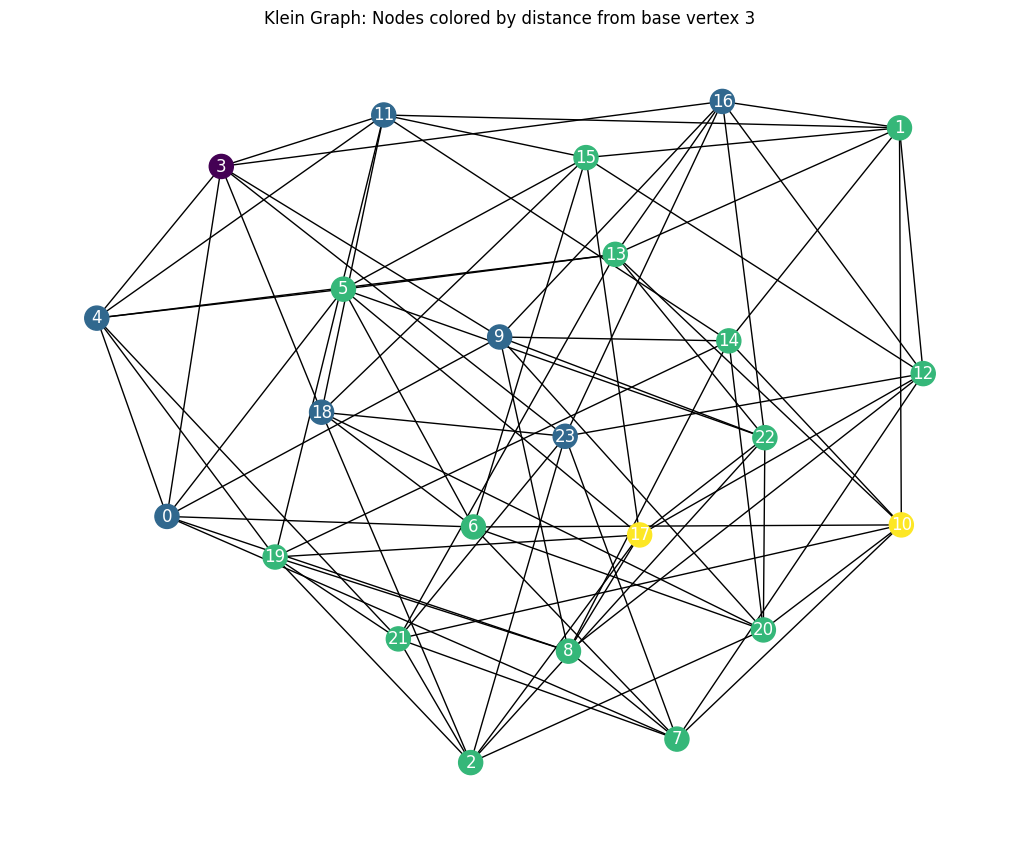

In [69]:
G = nx.from_numpy_array(A)

# Prepare node colors based on subconstituent membership
node_colors = ['None'] * n
color_map = plt.colormaps['viridis'].resampled(D + 1)

for distance, nodes_at_dist in subc.items():
    color = color_map(distance)
    for node in nodes_at_dist:
        node_colors[node] = color

fig = plt.figure(figsize=(10, 8))
nx.draw_spring(G, node_color=node_colors, with_labels=True, font_color='white')
plt.title(f"Klein Graph: Nodes colored by distance from base vertex {base}")
plt.show()

Explanation of colors:
The 'viridis' colormap ranges from dark purple (for low values/distances)
to bright yellow (for high values/distances).
- Darker nodes (purple/blue) are closer to the base vertex.
- Lighter nodes (green/yellow) are further away from the base vertex.
Specifically, the yellow vertices (nodes 10 and 17) are at the maximum distance
 (D=3) from the base vertex 3.